2.1 递归

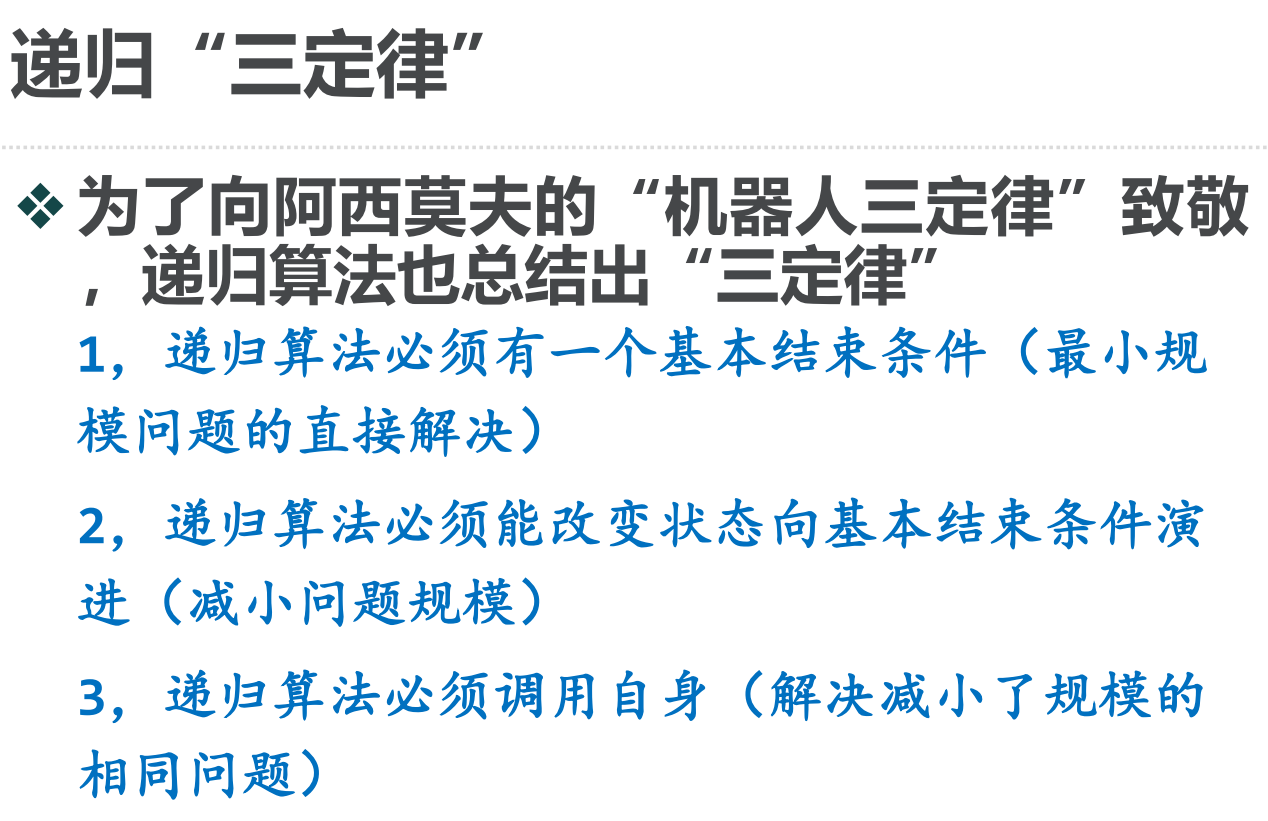

In [ ]:
def convert(num,base):
    if num >= base:
        return convert(num//base,base) + str(num%base)
    else:
        return str(num)

num = 1
base = 2
print(convert(num,base))

In [3]:
import turtle

In [ ]:
def tree(t,length):
    if length > 5:
        t.forward(length)
        t.right(20)
        tree(t,length-15)
        t.left(40)
        tree(t,length-15)
        t.right(20)
        t.backward(length)

t = turtle.Turtle()
t.left(90)
t.penup()
t.backward(100)
t.pendown()
t.pencolor('red')
t.pensize(2)
tree(t,75)
t.hideturtle()
turtle.done()

In [10]:
def draw(points,color):
    t.fillcolor(color)
    t.penup()
    t.goto(points["top"])
    t.pendown()
    t.begin_fill()
    t.goto(points["left"])
    t.goto(points["right"])
    t.goto(points["top"])
    t.end_fill()

def getmid(p1,p2):
    return ((p1[0]+p2[0])/2, (p1[1]+p2[1])/2)

def drawTrangle(points,n):
    color_list = ["red","blue","green","yellow","cyan"]
    if n > 0:
        draw(points,color_list[n-1])

        point_left ={
            "left":points["left"],
            "top":getmid(points["left"],points["top"]),
            "right":getmid(points["left"],points["right"]),
        }

        point_top = {
            "left":getmid(points["left"],points["top"]),
            "top":points["top"],
            "right":getmid(points["top"],points["right"]),
        }

        point_right ={
            "left":getmid(points["left"],points["right"]),
            "top":getmid(points["top"],points["right"]),
            "right":points["right"],
        }
        drawTrangle(point_left,n-1)
        drawTrangle(point_top,n-1)
        drawTrangle(point_right,n-1)

t = turtle.Turtle()

points = {
    "left":(-200,-100),
    "top":(0,200),
    "right":(200,-100),
}

drawTrangle(points,5)
turtle.done()


汉诺塔问题：

In [24]:
def movedisk(height,frompole,topole):
    print("将棋子%d由柱子%d移动到柱子%d"%(height,frompole,topole))

def movetower(height,frompole,withpole,topole):
    if height >= 1:
        movetower(height-1,frompole,topole,withpole)
        movedisk(height,frompole,topole)
        movetower(height-1,withpole,frompole,topole)

height = 3
frompole = 1
withpole = 2
topole = 3

movetower(height,frompole,withpole,topole)



将棋子1由柱子1移动到柱子3
将棋子2由柱子1移动到柱子2
将棋子1由柱子3移动到柱子2
将棋子3由柱子1移动到柱子3
将棋子1由柱子2移动到柱子1
将棋子2由柱子2移动到柱子3
将棋子1由柱子1移动到柱子3


In [ ]:
class Maze:
    def __init__(self,):
        text = open("maze.txt","r")
        Maze_list = []
        row = 0
        for line in text:
            maze_list = []#小列表和列的设置要放在大循环里面，否则数据会越来越大，表示的也不再是某一行的数据
            col = 0
            for ch in line[:-1]:
                maze_list.append(ch)
                if ch == "s":
                    self.startrow = row
                    self.startcol = col
                col = col + 1
            row = row + 1
            Maze_list.append(maze_list)

贪心问题的找零兑换问题

In [9]:
def Exchange(money):
    if money >= 25:
        num = money//25
        return  "%d个25,"%num + Exchange(money%25)
    elif money >= 10:
        num = money//10
        return "%d个10,"%num + Exchange(money%10)
    elif money >= 5:
        num = money//5
        return "%d个5,"%num + Exchange(money%5)
    else:
        num = money
        return "%d个1,"%num

print(Exchange(144))

5个25,1个10,1个5,4个1,


递归的硬币找零问题

思路：先减小问题的规模，然后找到小规模问题的最优解，并将其应用到较大规模问题的解决上。

In [6]:
def exchange(coinlist,change,know_list):
    min_coin = change
    if change in coinlist:
        know_list[change] = 1
        return 1
    elif know_list[change] != 0:
        return know_list[change]
    else:
        for coin in [c for c in coinlist if c<=change]:
            coin_num = 1 + exchange(coinlist,change-coin,know_list)
            if  coin_num < min_coin:
                min_coin = coin_num
        know_list[change] = min_coin

    return know_list[change]

coinlist = [1,5,21,25]
print(exchange(coinlist,84,[0]*85))


4


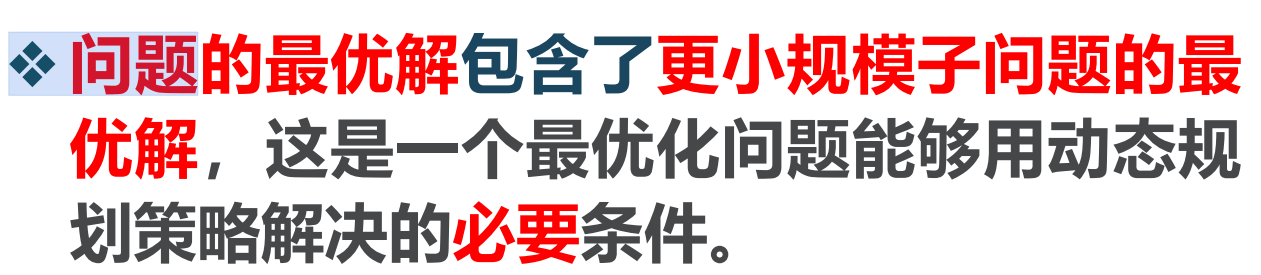

动态规划找零算法

In [88]:
def dpMakechange(change,coinlist,used_list,min_list):#used_list用于存放当前使用的硬币数，而min_list用以存放当前零钱使用的最小硬币数。
    for cents in range(1,change+1):
        min_list[cents] = cents
        for c in [c for c in coinlist if c<=cents]:
            if 1 + min_list[cents-c] < min_list[cents]:
                min_list[cents] = 1 + min_list[cents-c]
                used_list[cents] = c
    return min_list[change], used_list

def checkcoin(change,used_list):
    while change:
        print(used_list[change])
        change = change - used_list[change]

coinlist = [1,5,21,25]
used_list = [0]*64
x,y = dpMakechange(63,coinlist,used_list,[0]*64)
print(x)
checkcoin(63,y)

3
21
21
21


In [7]:
list = [None,{"w":2,"v":3},{"w":3,"v":4},
             {"w":4,"v":8},{"w":5,"v":8},
                {"w":9,"v":10}]

def thief(list,weight):
    m ={}
    for i in range(len(list)):
        for j in range(weight+1):
            if i ==0:#物品为空
                m[(0,j)] = 0#此时无论背包容量多大价值都为0
            elif list[i]["w"] > j:#当前物品重量达于背包重量，这个物品肯定放不下，当前的最大值为在重量为j的情况下取前i-1个物品的值
                m[(i,j)] = m[(i-1,j)]
            else:
                m[(i,j)] = max(m[i-1,j],m[i-1,j-list[i]["w"]]+list[i]["v"])
    return m[(5,20)]


print(thief(list,20))


29


In [117]:
list = [None,(2,3),(3,4),(4,8),(5,8),(9,10)]
m = {}

def steal(i,weight):
    if i ==0 or weight==0:
        m[(i,weight)] = 0

    if (i,weight) in m:
        return m[(i,weight)]

    if list[i][0] > weight:
        m[(i,weight)] = steal(i-1,weight)

    else:
        m[(i,weight)] = max(steal(i-1,weight-list[i][0])+list[i][1],steal(i-1,weight))

    return m[(i,weight)]

print(steal(5,20))

29
